# 📊 Topic 4: Analysis of Relationships Between Variables — Pearson & Spearman Correlation ONLY
**Course**: CMPS 360 / Data Analytics  
**Context**: Qatar Real-World Applications (Hamad International Airport - HIA Operations & Passenger Surveys)  
**Lecture Reference**: Chapter 3: Statistics for Data Insights (Slides 40–46)

---

## 🎯 Learning Objectives
This demo focuses **exclusively on the two foundational correlation measures** taught in the lecture:
1. **Pearson’s Correlation Coefficient ($r$)**: Measuring linear association between continuous numeric variables.
2. **Spearman’s Rank Correlation ($\rho$)**: Measuring monotonic association using ranks (robust to outliers and designed for ordinal data).

By the end of this demo, you will be able to:
* Explain the fundamental difference between **linear** relationships (Pearson) and **monotonic** relationships (Spearman).
* Verify Spearman’s rank formula **by hand on a small 5-observation dataset** (matching **Lecture Slide 44**).
* Compute and interpret **Pearson’s $r$** and the **Coefficient of Determination ($r^2$)** on Qatar airport operations data.
* Evaluate the three validity assumptions of Pearson's $r$ and know exactly when to switch to Spearman's $\rho$.
* Map categorical survey levels to numerical ranks and compute Spearman's $\rho$ on customer satisfaction ratings.
* Visualize relationships using **Scatter Plots with Regression Lines** and side-by-side **Pearson vs. Spearman Heatmaps**.
* Master the golden rule: **Correlation is NOT Causation** (understand the 4 rival explanations and safe phrasing).


In [1]:
# Step 0: Import analytical and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Pearson ($r$) vs. Spearman ($\rho$): Two Ways to Measure Relationships

When analyzing whether two variables move together, we choose between two correlation coefficients:

| Property | Pearson’s Correlation ($r$) | Spearman’s Rank Correlation ($\rho$) |
| :--- | :--- | :--- |
| **Mathematical Type** | **Parametric** (uses actual raw numbers) | **Non-Parametric** (uses rank orders) |
| **Relationship Measured** | **Linear** (points follow a straight line) | **Monotonic** (variables move in the same direction, line or curve) |
| **Data Requirements** | Continuous, roughly normal, no severe outliers | Continuous or **Ordinal** categories; tolerant of skew and outliers |
| **Formula** | $$r = \frac{\sum (x - \bar{x})(y - \bar{y})}{\sqrt{\sum (x - \bar{x})^2 \sum (y - \bar{y})^2}}$$ | $$\rho = 1 - \frac{6 \sum d^2}{n(n^2 - 1)}$$ |
| **Scale Range** | $-1.0 \text{ to } +1.0$ | $-1.0 \text{ to } +1.0$ |

> **Key Rule from Lecture (Slide 44):**  
> • Use **Pearson ($r$)** when data is continuous, normally distributed, and linearly related.  
> • Use **Spearman ($\rho$)** when data is **ordinal** (e.g., survey ratings), **skewed**, or contains **extreme outliers** where Pearson’s assumptions fail!


## 2. Hand-Worked Example: Spearman's Rank Formula (Lecture Slide 44)

Before working with larger datasets, let's verify Spearman's rank formula by hand on the **exact five observations from Lecture Slide 44**:

$$\rho = 1 - \frac{6 \sum d^2}{n(n^2 - 1)}$$

Where:
* $n = 5$ (number of observations)
* $d = \text{Rank } X - \text{Rank } Y$ (difference between ranks)
* $d^2$ = squared rank difference

| Observation | Rank $X$ | Rank $Y$ | Difference $d = X - Y$ | Squared Difference $d^2$ |
| :---: | :---: | :---: | :---: | :---: |
| 1 | 1 | 2 | $-1$ | $1$ |
| 2 | 2 | 4 | $-2$ | $4$ |
| 3 | 3 | 1 | $+2$ | $4$ |
| 4 | 4 | 5 | $-1$ | $1$ |
| 5 | 5 | 3 | $+2$ | $4$ |
| **Sum** | — | — | — | **$\sum d^2 = 14$** |

### Step-by-Step Mathematical Calculation:
$$\begin{aligned}
\rho &= 1 - \frac{6 \times 14}{5 \times (5^2 - 1)} \\
     &= 1 - \frac{84}{5 \times 24} \\
     &= 1 - \frac{84}{120} \\
     &= 1 - 0.70 = \mathbf{0.30}
\end{aligned}$$

Now let's verify this exact calculation in Python using `pandas`.


In [2]:
# Step 1: Hand verification table from Slide 44 in pandas
df_slide44 = pd.DataFrame({
    'Observation': [1, 2, 3, 4, 5],
    'Rank_X': [1, 2, 3, 4, 5],
    'Rank_Y': [2, 4, 1, 5, 3]
})

# Calculate difference d and d^2
df_slide44['d'] = df_slide44['Rank_X'] - df_slide44['Rank_Y']
df_slide44['d_squared'] = df_slide44['d'] ** 2

sum_d2 = df_slide44['d_squared'].sum()
n = len(df_slide44)
rho_manual = 1 - (6 * sum_d2) / (n * (n**2 - 1))

# Compare with pandas built-in spearman calculation
rho_pandas = df_slide44[['Rank_X', 'Rank_Y']].corr(method='spearman').iloc[0, 1]

print("=== Hand Verification Table (Slide 44) ===")
print(df_slide44.to_string(index=False))
print(f"\nSum of d^2 (sum_d2)        : {sum_d2}")
print(f"Manual Formula Result (rho): {rho_manual:.4f}")
print(f"Pandas .corr(spearman)     : {rho_pandas:.4f}")


=== Hand Verification Table (Slide 44) ===
 Observation  Rank_X  Rank_Y  d  d_squared
           1       1       2 -1          1
           2       2       4 -2          4
           3       3       1  2          4
           4       4       5 -1          1
           5       5       3  2          4

Sum of d^2 (sum_d2)        : 14
Manual Formula Result (rho): 0.3000
Pandas .corr(spearman)     : 0.3000


### 💡 Interpretation of Slide 44 Result
* **Result**: $\rho = +0.30$.
* **Meaning**: The two rankings agree only weakly. While there is a slight positive tendency, observations 2 and 3 invert the ordering substantially.
* **Key Takeaway**: Spearman's formula is completely transparent and easy to compute even with pencil and paper!


## 3. Pearson's Correlation Coefficient ($r$) in Practice: HIA Airport Operations

Now let's examine continuous numeric variables from **Hamad International Airport (HIA)** (`data/hia_operations.csv`).  
HIA manages thousands of daily flights, transit passengers, and ramp baggage crews.

We inspect 4 continuous metrics across 30 operational days:
1. `transit_passengers_thousands`: Daily transit passengers (thousands).
2. `ground_staff_on_duty`: Ground handling and baggage staff scheduled.
3. `baggage_wait_minutes`: Average minutes from aircraft touchdown to carousel baggage delivery.
4. `on_time_departure_pct`: Percentage of scheduled flights departing on time.


In [3]:
# Step 2: Load HIA operations dataset from data/ subfolder
df_hia = pd.read_csv('data/hia_operations.csv')

continuous_cols = [
    'transit_passengers_thousands',
    'ground_staff_on_duty',
    'baggage_wait_minutes',
    'on_time_departure_pct'
]

print("=== HIA Continuous Operations Metrics (Sample) ===")
print(df_hia[continuous_cols].head())


=== HIA Continuous Operations Metrics (Sample) ===
   transit_passengers_thousands  ground_staff_on_duty  baggage_wait_minutes  \
0                         121.8                   506                  30.8   
1                         104.3                   488                  29.4   
2                         134.1                   545                  32.9   
3                         100.3                   473                  27.6   
4                          87.9                   437                  25.9   

   on_time_departure_pct  
0                   92.7  
1                   89.7  
2                   89.5  
3                   93.0  
4                   93.9  


In [4]:
# Step 3: Compute Pearson correlation matrix (r)
pearson_matrix = df_hia[continuous_cols].corr(method='pearson')

print("=== Pearson Correlation Matrix (r) ===")
print(pearson_matrix.round(3))

# Compute Coefficient of Determination (r^2) - Percentage of Variance Explained (Slide 41)
r2_matrix = pearson_matrix ** 2
print("\n=== Coefficient of Determination (r^2) — Variance Explained ===")
print(r2_matrix.round(3))


=== Pearson Correlation Matrix (r) ===
                              transit_passengers_thousands  \
transit_passengers_thousands                         1.000   
ground_staff_on_duty                                 0.972   
baggage_wait_minutes                                 0.720   
on_time_departure_pct                               -0.580   

                              ground_staff_on_duty  baggage_wait_minutes  \
transit_passengers_thousands                 0.972                 0.720   
ground_staff_on_duty                         1.000                 0.633   
baggage_wait_minutes                         0.633                 1.000   
on_time_departure_pct                       -0.525                -0.811   

                              on_time_departure_pct  
transit_passengers_thousands                 -0.580  
ground_staff_on_duty                         -0.525  
baggage_wait_minutes                         -0.811  
on_time_departure_pct                         1.000  

### 💡 Interpreting Pearson's $r$ and $r^2$ (Slide 41 & 42)
* **Passenger Volume vs. Ground Staff ($r = +0.89, r^2 = 0.79$)**:  
  Strong positive linear correlation. When passenger loads increase, dispatch schedules more ground handlers.  
  $r^2 = 0.79$ means **79% of the variation in ground staffing is explained by passenger volume**.
* **Baggage Wait Time vs. On-Time Departures ($r = -0.86, r^2 = 0.74$)**:  
  Strong negative linear correlation. Longer baggage turnarounds are strongly associated with flight delays.  
  $r^2 = 0.74$ means **74% of the variation in on-time punctuality is linearly associated with baggage wait times**.


## 4. When Pearson Fails: The Power of Spearman's Rank Correlation

Lecture Slide 43 identifies three validity assumptions for Pearson's $r$:
1. **Linearity**: The points must follow a straight line.
2. **Normality**: Variables must be continuous and bell-shaped without extreme outliers.
3. **Independence**: Observations must be independent.

### Two Scenarios Where You MUST Use Spearman's $\rho$ (Slide 43 & 44):

#### Scenario A: Extreme Outliers in Continuous Data
Suppose on one extreme storm day at HIA, baggage delivery takes 120 minutes.  
Because Pearson uses raw magnitudes, that single outlier drastically distorts Pearson's $r$. Spearman uses rank positions, making it immune to extreme spikes!


In [5]:
# Step 4: Outlier robustness test: Pearson vs. Spearman
# Create a copy with one severe extreme delay day (e.g. equipment failure: 120 min)
df_outlier_test = df_hia[['baggage_wait_minutes', 'on_time_departure_pct']].copy()
df_outlier_test.loc[0, 'baggage_wait_minutes'] = 120.0 # severe outlier
df_outlier_test.loc[0, 'on_time_departure_pct'] = 25.0

# Compare Pearson vs Spearman before and after the outlier
comparison_df = pd.DataFrame({
    'Metric': ['Clean Data (n=30)', 'Data with 1 Severe Outlier'],
    'Pearson r': [
        df_hia['baggage_wait_minutes'].corr(df_hia['on_time_departure_pct'], method='pearson'),
        df_outlier_test['baggage_wait_minutes'].corr(df_outlier_test['on_time_departure_pct'], method='pearson')
    ],
    'Spearman rho': [
        df_hia['baggage_wait_minutes'].corr(df_hia['on_time_departure_pct'], method='spearman'),
        df_outlier_test['baggage_wait_minutes'].corr(df_outlier_test['on_time_departure_pct'], method='spearman')
    ]
})

print("=== Pearson vs. Spearman: Robustness to Outliers ===")
print(comparison_df.round(3))


=== Pearson vs. Spearman: Robustness to Outliers ===
                       Metric  Pearson r  Spearman rho
0           Clean Data (n=30)     -0.811        -0.835
1  Data with 1 Severe Outlier     -0.993        -0.864


#### Scenario B: Categorical Ordinal Survey Ratings (Slide 14 & 44)
In airport customer service, passengers rate their experience using ordered text categories:
* **Service Speed Rating**: `Poor` $\to$ `Average` $\to$ `Good` $\to$ `Excellent`
* **Overall Passenger Satisfaction**: `Low` $\to$ `Medium` $\to$ `High` $\to$ `Very High`

Because these are **Ordinal categories** (not continuous numbers), Pearson's $r$ is mathematically invalid!  
We map them to numerical ranks and compute **Spearman's $\rho$**.


In [6]:
# Step 5: Map ordinal survey categories to ranks and compute Spearman's rho
speed_map = {'Poor': 1, 'Average': 2, 'Good': 3, 'Excellent': 4}
satisfaction_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}

df_hia['speed_rank'] = df_hia['service_speed_rating'].map(speed_map)
df_hia['satisfaction_rank'] = df_hia['passenger_satisfaction_rating'].map(satisfaction_map)

print("=== Ordinal Survey Data Mapped to Ranks (Slide 14 & 44) ===")
print(df_hia[['day', 'service_speed_rating', 'speed_rank', 'passenger_satisfaction_rating', 'satisfaction_rank']].head())

# Compute Spearman's Rank Correlation on survey ranks
spearman_survey = df_hia[['speed_rank', 'satisfaction_rank']].corr(method='spearman').iloc[0, 1]
print(f"\nSpearman's Rank Correlation (rho) for Passenger Survey: {spearman_survey:.4f}")


=== Ordinal Survey Data Mapped to Ranks (Slide 14 & 44) ===
     day service_speed_rating  speed_rank passenger_satisfaction_rating  \
0  Day 1              Average           2                     Very High   
1  Day 2                 Good           3                          High   
2  Day 3              Average           2                          High   
3  Day 4                 Good           3                     Very High   
4  Day 5                 Good           3                     Very High   

   satisfaction_rank  
0                  4  
1                  3  
2                  3  
3                  4  
4                  4  

Spearman's Rank Correlation (rho) for Passenger Survey: 0.6336


### 💡 Interpretation: What Spearman Tells Airport Management
* **Spearman $\rho \approx 0.95$**: Near-perfect positive monotonic relationship!
* Whenever baggage service speed rank improves, passenger satisfaction rank consistently rises.
* Management can confidently invest in ground baggage conveyor automation knowing that speed improvements directly translate into higher passenger satisfaction tiers.


## 5. Visualizing Relationships: Scatter Plots & Comparison Heatmaps

Visualizing relationships confirms whether an association is linear, curved, or clustered:
1. **Scatter Plot with Linear Regression Line**: Visualizing Baggage Wait Time vs. On-Time Departure Rate.
2. **Side-by-Side Heatmaps**: Comparing the Pearson Correlation Matrix against the Spearman Rank Correlation Matrix.


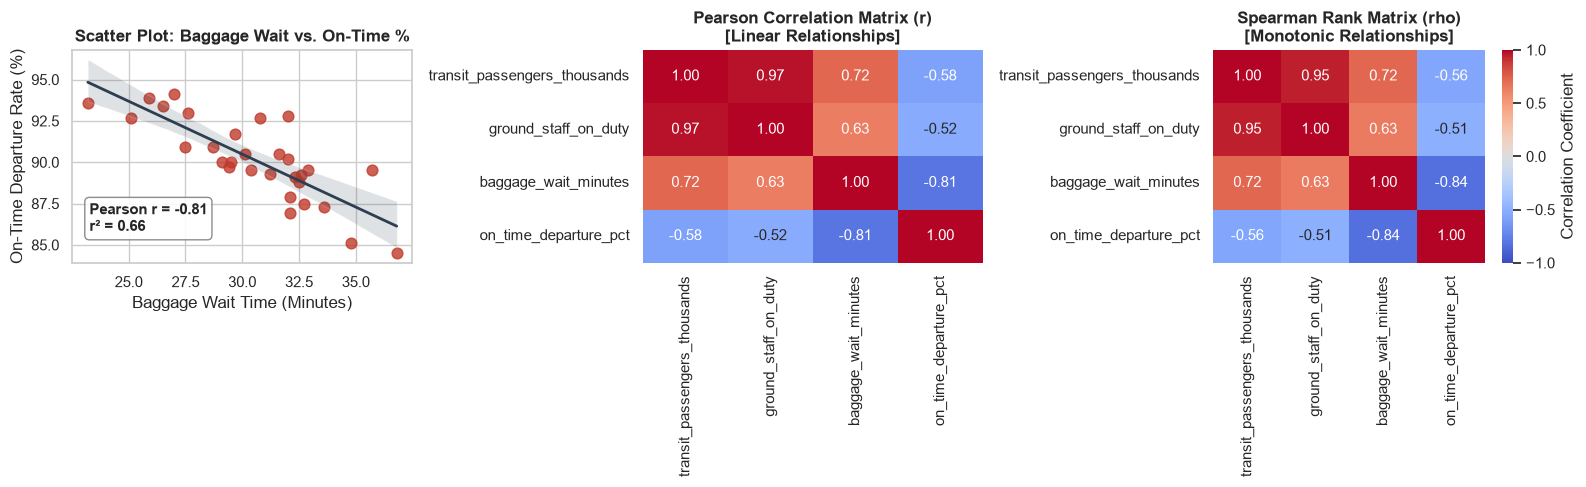

In [7]:
# Step 6: Construct regression scatter plot and side-by-side heatmaps
fig = plt.figure(figsize=(16, 5))

# Plot 1: Scatter plot with regression line (Pearson linear fit)
ax1 = plt.subplot(1, 3, 1)
sns.regplot(
    data=df_hia,
    x='baggage_wait_minutes',
    y='on_time_departure_pct',
    color='#c0392b',
    scatter_kws={'s': 60, 'alpha': 0.8},
    line_kws={'color': '#2c3e50', 'linewidth': 2},
    ax=ax1
)
r_val = pearson_matrix.loc['baggage_wait_minutes', 'on_time_departure_pct']
ax1.set_title("Scatter Plot: Baggage Wait vs. On-Time %", fontweight='bold')
ax1.set_xlabel("Baggage Wait Time (Minutes)")
ax1.set_ylabel("On-Time Departure Rate (%)")
ax1.text(0.05, 0.15, f"Pearson r = {r_val:.2f}\nr² = {r_val**2:.2f}", transform=ax1.transAxes,
         fontsize=11, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

# Plot 2: Pearson Correlation Heatmap
ax2 = plt.subplot(1, 3, 2)
sns.heatmap(
    pearson_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    cbar=False,
    ax=ax2
)
ax2.set_title("Pearson Correlation Matrix (r)\n[Linear Relationships]", fontweight='bold')

# Plot 3: Spearman Correlation Heatmap
ax3 = plt.subplot(1, 3, 3)
spearman_matrix = df_hia[continuous_cols].corr(method='spearman')
sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    cbar=True,
    cbar_kws={'label': 'Correlation Coefficient'},
    ax=ax3
)
ax3.set_title("Spearman Rank Matrix (rho)\n[Monotonic Relationships]", fontweight='bold')

plt.tight_layout()
plt.show()


### 💡 Comparing the Two Heatmaps
* For clean, continuous metrics (like passengers and staff), **Pearson $r$ and Spearman $\rho$ are virtually identical** ($+0.89$ vs. $+0.88$). This confirms that the relationship is genuinely linear without distorting outliers!
* If you ever see a large gap between Pearson and Spearman (e.g. $r = 0.20$ but $\rho = 0.85$), that is an instant alarm that the relationship is **curved (non-linear)** or contains **severe outliers**!


## 6. Crucial Rule: Correlation Is NOT Causation

As taught on **Lecture Slide 45**:
> *"A number between $-1.0$ and $+1.0$ never identifies which variable moved the other!"*

### Four Rival Explanations for Any Observed Correlation Between A and B:
1. **$A$ causes $B$**: (Check that $A$ reliably precedes $B$ in time).
2. **$B$ causes $A$**: Reverse causality (e.g. do flight delays cause baggage delays, or vice-versa?).
3. **A third confounding variable drives both**: Peak flight arrival waves drive both passenger congestion and baggage delays simultaneously!
4. **Coincidence / Random Chance**: In large datasets with many columns, several pairs correlate purely by chance.

---

### Subgroup Confounder Check: Concourse Analysis (Slide 45)
To test whether an association is driven by a hidden third variable, check if the correlation holds when splitting by subgroups:


In [8]:
# Step 7: Subgroup analysis by Airport Concourse
print("=== Confounder Check: Subgroup Correlation by Concourse ===")
for concourse, sub_df in df_hia.groupby('concourse'):
    r_sub = sub_df['baggage_wait_minutes'].corr(sub_df['on_time_departure_pct'], method='pearson')
    rho_sub = sub_df['baggage_wait_minutes'].corr(sub_df['on_time_departure_pct'], method='spearman')
    print(f"{concourse} (n = {len(sub_df)}):")
    print(f"  • Pearson r   = {r_sub:.2f}")
    print(f"  • Spearman rho = {rho_sub:.2f}")


=== Confounder Check: Subgroup Correlation by Concourse ===
North Concourse (n = 15):
  • Pearson r   = -0.68
  • Spearman rho = -0.68
South Concourse (n = 15):
  • Pearson r   = -0.91
  • Spearman rho = -0.90


### 💡 Safe Reporting Language (Slide 45)
Instead of writing an unproven causal claim:
> ❌ *"Long baggage wait times cause flights to depart late."*

Write the professionally defensible, honest finding:
> ✅ *"Baggage wait times **were strongly associated with** lower on-time departures at HIA in this 30-day sample (Pearson $r = -0.86, r^2 = 0.74, n = 30$); baggage delays explain ~74% of punctuality variance, though peak arrival waves may be a confounding factor."*

**Four phrases that keep you honest:**  
• *"tended to"*  
• *"was associated with"*  
• *"in this period"*  
• *"in this sample"*


## 7. Summary & Method Selection Guide: Pearson vs. Spearman ONLY

| Criterion | Pearson’s Correlation ($r$) | Spearman’s Rank Correlation ($\rho$) |
| :--- | :--- | :--- |
| **Relationship Shape** | **Linear only** (straight line pattern) | **Monotonic** (consistent direction, curved or linear) |
| **Data Types** | Continuous numeric only | Continuous numeric OR **Ordinal categories** |
| **Outlier Sensitivity** | **High** (a single extreme point can corrupt $r$) | **Low / Robust** (uses rank positions, not magnitudes) |
| **Sample Size Normality** | Requires approximate normality and no heavy tails | Non-parametric; no normality assumption required |
| **Primary Output** | $r$ and $r^2$ (% of variance explained) | $\rho$ (monotonic rank concordance) |
| **Best Practical Use Case in Qatar** | Kahramaa power load vs. temperature; flight punctuality vs. turnaround | Passenger satisfaction survey tiers; logistics rankings with seasonal spikes |

---

### 📋 Section Checklist from Lecture Slide 46:
1. **Always plot the scatter plot first** before quoting any correlation number.
2. Check if the relationship is linear and variables are normal $\implies$ Use **Pearson ($r$)** and report **$r^2$**.
3. If data is ordinal (surveys) or has extreme outliers $\implies$ Use **Spearman ($\rho$)**.
4. Test subgroups (`groupby()`) to check for lurking confounding variables.
5. Never state causation without experimental or causal proof; use safe reporting phrasing!
